In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('sales_data_with_discounts.csv')
df.head()

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [3]:
# Select numerical columns
numerical_columns = df.select_dtypes(include=['int64','float64'])

print("Numerical Columns:")
print(numerical_columns.columns)

Numerical Columns:
Index(['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)',
       'Discount Amount', 'Net Sales Value'],
      dtype='object')


In [4]:
# Mean
mean_values = numerical_columns.mean()
print("Mean:\n", mean_values)

# Median
median_values = numerical_columns.median()
print("\nMedian:\n", median_values)

# Mode
mode_values = numerical_columns.mode()
print("\nMode:\n", mode_values)

# Standard Deviation
std_values = numerical_columns.std()
print("\nStandard Deviation:\n", std_values)

Mean:
 Volume                   5.066667
Avg Price            10453.433333
Total Sales Value    33812.835556
Discount Rate (%)       15.155242
Discount Amount       3346.499424
Net Sales Value      30466.336131
dtype: float64

Median:
 Volume                  4.000000
Avg Price            1450.000000
Total Sales Value    5700.000000
Discount Rate (%)      16.577766
Discount Amount       988.933733
Net Sales Value      4677.788059
dtype: float64

Mode:
      Volume  Avg Price  Total Sales Value  Discount Rate (%)  Discount Amount  \
0       3.0      400.0            24300.0           5.007822        69.177942   
1       NaN      450.0                NaN           5.055218        73.025199   
2       NaN      500.0                NaN           5.059801        93.649161   
3       NaN     1300.0                NaN           5.072124        94.682735   
4       NaN     8100.0                NaN           5.084108       102.705757   
..      ...        ...                ...                

In [5]:
df.describe()

,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
count,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000
mean,5.066667,10453.433333,33812.835556,15.155242,3346.499424,30466.336131
std,4.231602,18079.904840,50535.074173,4.220602,4509.902963,46358.656624
min,1.000000,290.000000,400.000000,5.007822,69.177942,326.974801
25%,3.000000,465.000000,2700.000000,13.965063,460.459304,2202.208645
50%,4.000000,1450.000000,5700.000000,16.577766,988.933733,4677.788059
75%,6.000000,10100.000000,53200.000000,18.114718,5316.495427,47847.912852
max,31.000000,60100.000000,196400.000000,19.992407,25738.022194,179507.479049


Mean → Average value of the column

Median → Middle value after sorting data

Mode → Most frequently occurring value

Standard Deviation → Shows how spread out the data is from the mean

If standard deviation is high, data is more spread.

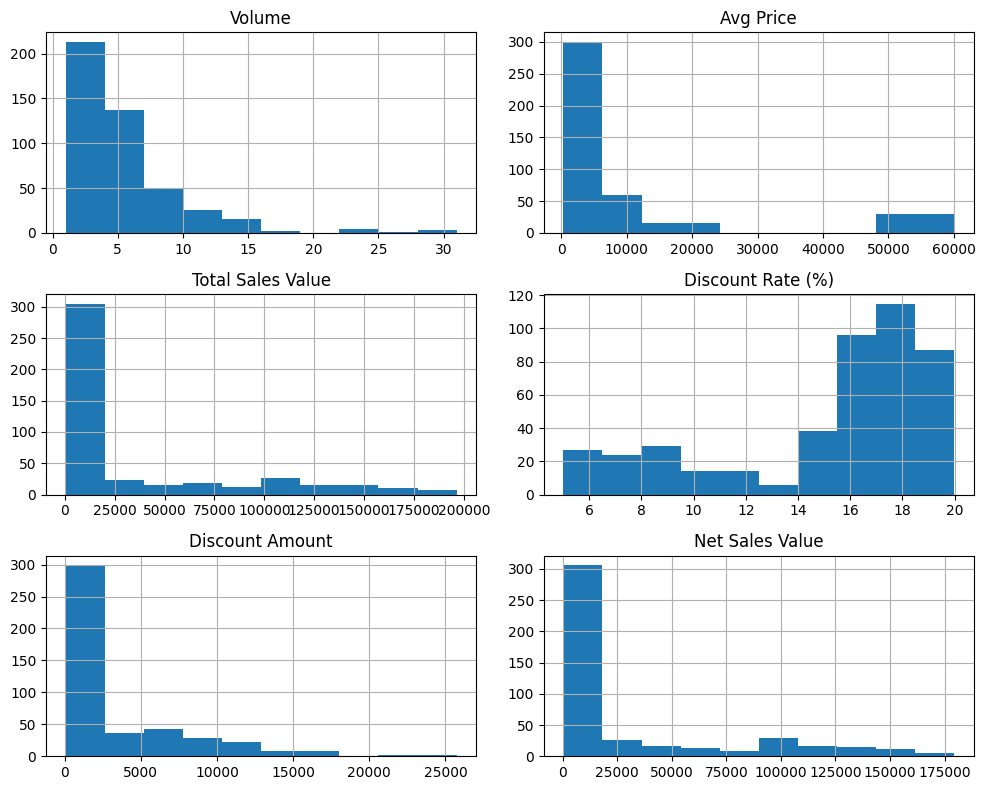

In [6]:
numerical_columns.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

Histogram shows distribution of data

We can identify skewness and outliers

If bars are symmetric → Normal distribution

If longer tail on one side → Skewed distribution

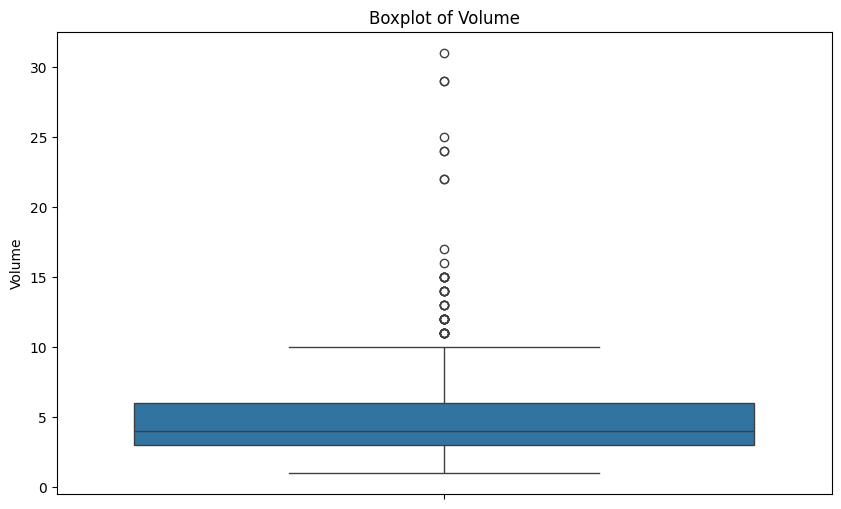

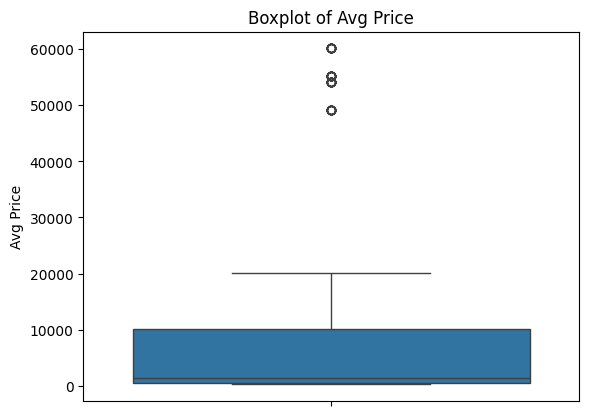

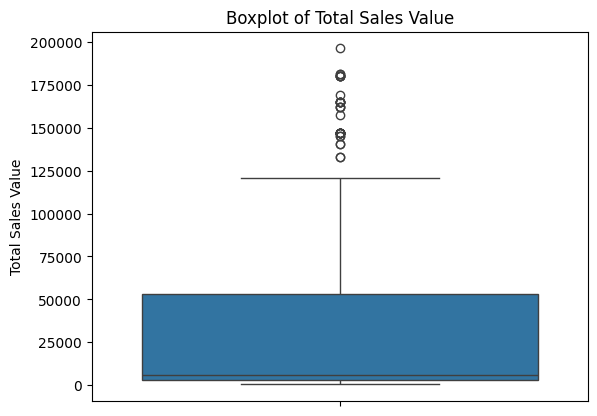

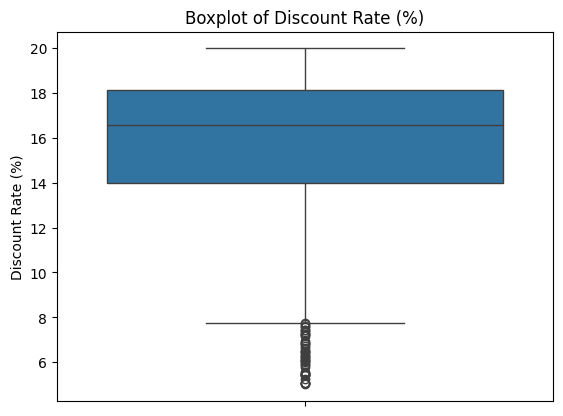

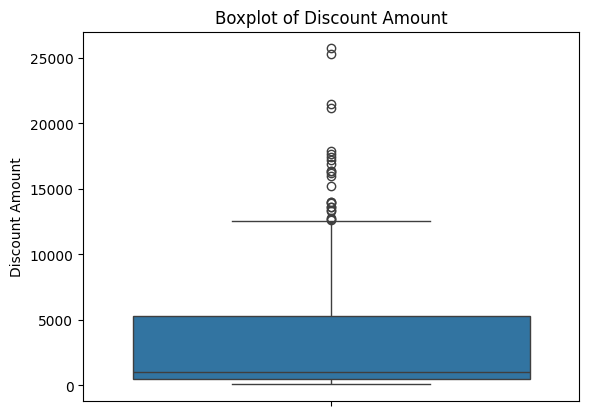

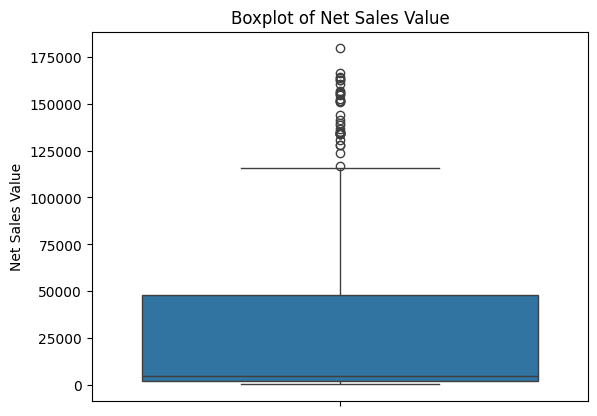

In [7]:
plt.figure(figsize=(10,6))

for column in numerical_columns:
    sns.boxplot(data=df[column])
    plt.title(f"Boxplot of {column}")
    plt.show()

Inference

Boxplot helps to identify:

Median

Quartiles

Outliers

Points outside the box range are outliers.

In [8]:
categorical_columns = df.select_dtypes(include=['object'])

print("Categorical Columns:")
print(categorical_columns.columns)

Categorical Columns:
Index(['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model'], dtype='object')


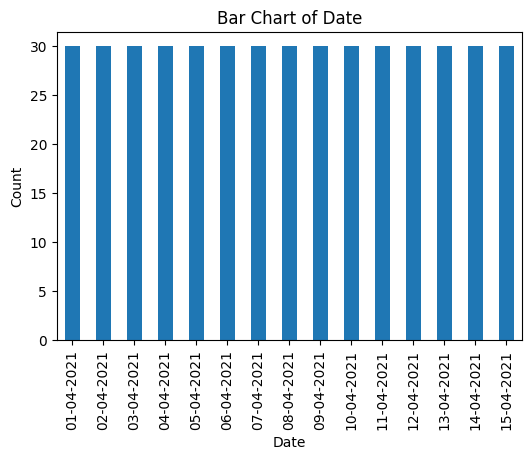

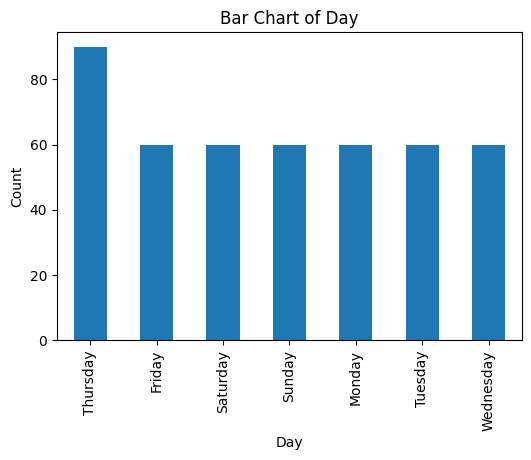

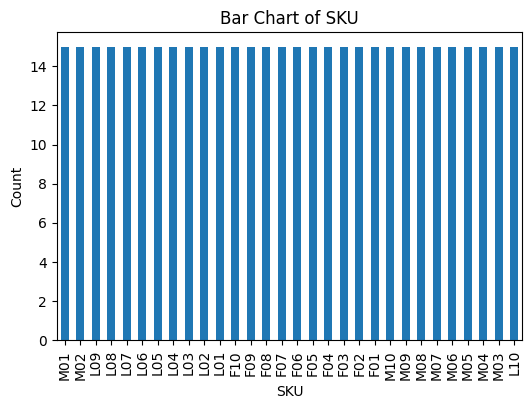

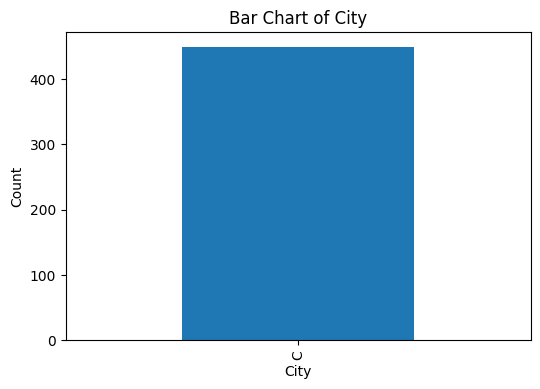

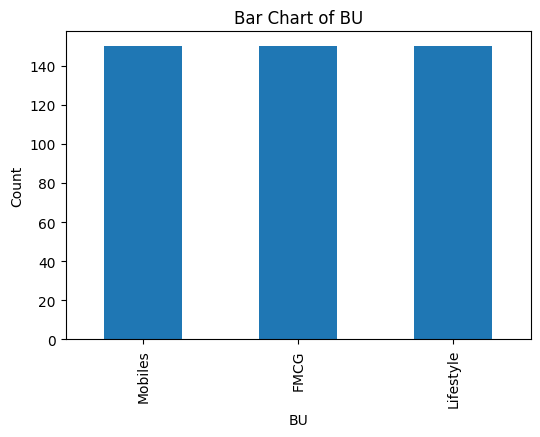

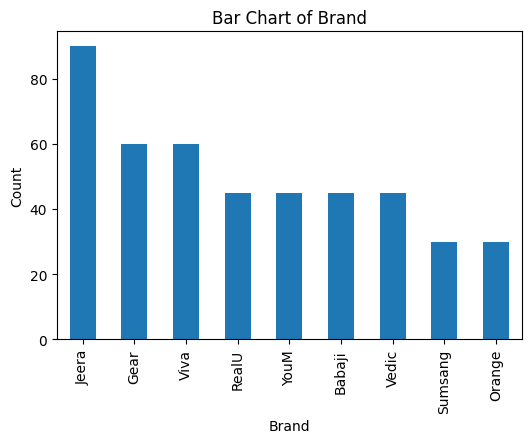

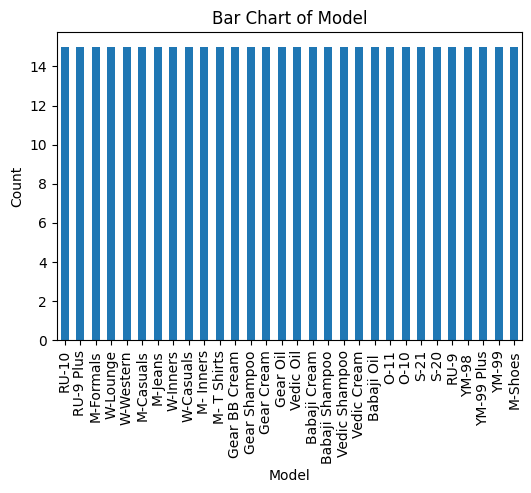

In [9]:
for column in categorical_columns:
    df[column].value_counts().plot(kind='bar', figsize=(6,4))
    
    plt.title(f"Bar Chart of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.show()

Inference

Bar charts help to understand:

Frequency of categories

Most common category

Least common category

This helps in understanding sales trends across categories.

In [10]:
df.isnull().sum()

Date                 0
Day                  0
SKU                  0
City                 0
Volume               0
BU                   0
Brand                0
Model                0
Avg Price            0
Total Sales Value    0
Discount Rate (%)    0
Discount Amount      0
Net Sales Value      0
dtype: int64

In [11]:
df.fillna(df.mean(numeric_only=True), inplace=True)

Conclusion

Descriptive statistics helped summarize the dataset using mean, median, mode, and standard deviation.

Histograms showed the distribution of numerical variables and helped identify skewness.

Boxplots helped detect outliers and understand the spread of the data.

Bar charts visualized the distribution of categorical variables.

Data preprocessing ensured missing values were handled properly for further analysis.